In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fahdahmad1911","key":"65c67c2834445325297a1804826d97ec"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

Dataset URL: https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
License(s): apache-2.0
 83% 332M/398M [00:00<00:00, 678MB/s]
100% 398M/398M [00:00<00:00, 565MB/s]


In [4]:
!unzip alzheimers-multiclass-dataset-equal-and-augmented.zip -d alzheimers
!ls alzheimers


Streaming output truncated to the last 5000 lines.
  inflating: alzheimers/combined_images/VeryMildDemented/a2479682-1520-4d4b-a819-0516809393db.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a252d5dd-3e86-42c4-83bb-52031cf5b9ff.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a2612e5a-c1f2-4781-803c-a6b471ded1b5.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a261d715-f3f3-4e30-842a-2e5441f00955.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a27aeaaf-b37f-4e15-ab3b-064daa19355b.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a27da9a4-1ed4-493f-af81-dd8a3c8adda2.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a280d3f6-c18d-424e-8f51-e924f5392c74.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a28780ec-8fc0-4d55-9596-0ae2663c6da4.jpg  
  inflating: alzheimers/combined_images/VeryMildDemented/a293bcd0-b371-4120-a3b5-f8c763b0fa95.jpg  
  inflating: alzheimers/combined_images/VeryMildD

In [45]:
# Core libraries
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# Data visualization
import os
from tqdm import tqdm, tnrange
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.io import imread, imshow, concatenate_images
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Model, load_model, save_model , Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50

# Additional TensorFlow components
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D,
    Dropout, Activation, concatenate, BatchNormalization, Add ,
)
from tensorflow.keras.layers import Flatten , Dense,GlobalAveragePooling2D
from tensorflow.keras import regularizers


In [46]:
def data_splitter(dir, classes,train_size=.8):
    """
    Custom generator that yields (X, y) batches
    directory: path to folder containing subfolders of classes
    classes: list of class names (subfolders)
    """
    if dir is None or len(classes)==0 or not (0.5 <= train_size <= 0.95):
      raise ValueError("error")
    file_paths, labels = [], []
    for idx, class_name in enumerate(classes):
        class_dir = os.path.join(dir, class_name)
        for fname in os.listdir(class_dir):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(idx)

    file_paths = np.array(file_paths)
    labels = np.array(labels)

    indices = np.arange(len(file_paths))
    np.random.shuffle(indices)
    file_paths, labels = file_paths[indices], labels[indices]
    train_x, dummy_x, train_y, dummy_y = train_test_split(file_paths,labels,train_size=train_size)
    val_x, test_x, val_y, test_y = train_test_split(dummy_x,dummy_y,test_size=.5)

    return train_x, train_y, val_x, val_y, test_x, test_y



In [47]:
classes = ["MildDemented","ModerateDemented","NonDemented","VeryMildDemented"]
dir = "/content/alzheimers/combined_images"
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(dir, classes,train_size=.8)
print(train_x.shape , train_y.shape)
print(test_x.shape , test_y.shape)
print(val_x.shape , val_y.shape)

(35200,) (35200,)
(4400,) (4400,)
(4400,) (4400,)


In [48]:
def plot_pred( X , y_true , y_pred, num_of_rows , figsize=(10,10)):
  if len(X) < num_of_rows or  not (len(X)==len(y_true)==len(y_pred)):
    print("there is an error")
  else:
    classes = ["MildDemented","ModerateDemented","NonDemented","VeryMildDemented"]
    plt.figure(figsize=figsize)
    for i in range (num_of_rows):
      img = X[i]
      true =np.argmax(y_true[i])
      pred = np.argmax(y_pred[i])
      plt.subplot(num_of_rows,1,i+1)
      plt.imshow(img)
      plt.title(f"True : {classes[true]}   Prediction :{classes[pred]} ")
      plt.axis("off")

    plt.tight_layout()
    plt.show()

In [57]:
def prepare(file_paths, labels, classes, target_size=(180,180)):
    X = np.empty((len(file_paths), target_size[1], target_size[0], 3), dtype=np.float32)
    for i, path in enumerate(file_paths):
        img = cv2.imread(path)
        img = cv2.resize(img, target_size)
        img = img.astype("float32") / 255.0
        X[i] = img
    Y = to_categorical(labels, num_classes=len(classes))
    return X, Y


In [50]:
def evaluate_model(y_true, y_pred):
    """
    Evaluate a multi-class classifier with confusion matrix, classification report,
    bar plots of precision/recall/F1, and ROC curves.

    y_true: numpy array of true labels (one-hot or integer class indices)
    y_pred: numpy array of predictions (softmax probs or logits)
    class_names: list of class names
    """

    # Convert to class indices if one-hot encoded
    class_names = ["MildDemented","ModerateDemented","NonDemented","VeryMildDemented"]
    if y_true.ndim > 1:
        y_true_classes = np.argmax(y_true, axis=1)
    else:
        y_true_classes = y_true

    y_pred_classes = np.argmax(y_pred, axis=1)

    # ---------------- Confusion Matrix ---------------- #
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # ---------------- Classification Report ---------------- #
    print("\nClassification Report:\n")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    # ---------------- Precision/Recall/F1 Bar Plot ---------------- #
    prec, rec, f1, support = precision_recall_fscore_support(y_true_classes, y_pred_classes)
    df_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Support": support
    })

    plt.figure(figsize=(10,6))
    df_metrics.set_index("Class")[["Precision","Recall","F1-Score"]].plot(kind="bar", ax=plt.gca())
    plt.title("Precision, Recall, F1-Score per Class")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.legend(loc="lower right")
    plt.show()

    # ---------------- ROC Curves ---------------- #
    y_true_bin = label_binarize(y_true_classes, classes=range(len(class_names)))
    plt.figure(figsize=(8,6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves per Class")
    plt.legend()
    plt.show()

    return df_metrics




In [52]:
WIDTH = 180
HEIGHT = 180
batch_size = 32
LR = 1e-4
EPOCHS = 30
ES = EarlyStopping(
    monitor = "val_loss",
    patience =10,
    mode ="min",
    restore_best_weights=True
)

RL = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 3,
    mode ="min",
    factor = .5,
    verbose=1
)

MCP = ModelCheckpoint(
    "Model.h5",
    monitor="val_loss",
    verbose=1,
    save_best_only=True
)
callbacks=[RL,MCP,ES]

opt = Adam(learning_rate=LR)

In [53]:
def data_gen(file_paths,labels,batch_size=32,target_size=(180,180)):

    while True:

        for i in range(0, len(file_paths), batch_size):

            batch_paths = file_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            batch_images = []

            for path in batch_paths:
                img = cv2.imread(path)
                img = cv2.resize(img, target_size)
                img = img.astype("float32") / 255.0
                batch_images.append(img)

            X = np.array(batch_images)
            y = to_categorical(batch_labels, num_classes=len(classes))
            yield X, y


In [54]:
train_gen = data_gen(train_x,train_y,target_size=(WIDTH,HEIGHT),batch_size = 32)
val_gen = data_gen(val_x,val_y,target_size=(WIDTH,HEIGHT),batch_size = 32)
train_steps = len(train_x)//batch_size
val_steps = len(val_x)// batch_size

In [37]:
def res_inception_block(x, filters):
    shortcut = x

    # Branch 1: 1x1 conv
    branch1 = Conv2D(filters, (1,1), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)

    # Branch 2: 1x1 conv -> 3x3 conv
    branch2 = Conv2D(filters, (1,1), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)
    branch2 = Conv2D(filters, (3,3), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(branch2)

    # Branch 3: 1x1 conv -> 5x5 conv
    branch3 =Conv2D(filters, (1,1), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)
    branch3 =Conv2D(filters, (5,5), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(branch3)

    # Branch 4: 3x3 maxpool -> 1x1 conv
    branch4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    branch4 = Conv2D(filters, (1,1), padding='same', activation='relu',
                            kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(branch4)

    # Concatenate branches
    x = concatenate([branch1, branch2, branch3, branch4], axis=-1)

    # Residual connection (adjust shortcut if necessary)
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = Conv2D(x.shape[-1], (1,1), padding='same')(shortcut)
    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x


In [15]:
def build_res_inception(input_shape=(224,224,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Initial conv + maxpool
    x = Conv2D(64, (7,7), strides=2, padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x =MaxPooling2D((3,3), strides=2, padding='same')(x)

    # Residual Inception blocks
    x = res_inception_block(x, 32)
    x = res_inception_block(x, 64)

    x = MaxPooling2D((3,3), strides=2, padding='same')(x)

    x = res_inception_block(x, 128)
    x = res_inception_block(x, 128)

    # Global pooling and classifier
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='linear')(x)

    model = Model(inputs, outputs)
    return model


In [16]:
model = build_res_inception(num_classes=len(classes),input_shape=(WIDTH,HEIGHT,3))

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3451 - loss: 1.9767
Epoch 1: val_loss improved from inf to 1.25191, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 142s 107ms/step - accuracy: 0.3452 - loss: 1.9763 - val_accuracy: 0.5385 - val_loss: 1.2519 - learning_rate: 0.0010
Epoch 2/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5755 - loss: 1.0888
Epoch 2: val_loss improved from 1.25191 to 0.97887, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 138s 126ms/step - accuracy: 0.5756 - loss: 1.0888 - val_accuracy: 0.6015 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 3/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6576 - loss: 0.8542
Epoch 3: val_loss improved from 0.97887 to 0.70568, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.6577 - loss: 0.8542 - val_accuracy: 0.7051 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 4/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7393 - loss: 0.6801
Epoch 4: val_loss improved from 0.70568 to 0.63930, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 117s 106ms/step - accuracy: 0.7393 - loss: 0.6800 - val_accuracy: 0.7434 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 5/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8011 - loss: 0.5518
Epoch 5: val_loss improved from 0.63930 to 0.47793, saving model to Model.h5


...

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.9874 - loss: 0.1316 - val_accuracy: 0.9748 - val_loss: 0.1695 - learning_rate: 5.0000e-04
Epoch 19/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9885 - loss: 0.1266
Epoch 19: val_loss improved from 0.16954 to 0.16374, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.9885 - loss: 0.1266 - val_accuracy: 0.9778 - val_loss: 0.1637 - learning_rate: 5.0000e-04
Epoch 20/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9894 - loss: 0.1223
Epoch 20: val_loss did not improve from 0.16374
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.9894 - loss: 0.1223 - val_accuracy: 0.9725 - val_loss: 0.1751 - learning_rate: 5.0000e-04
Epoch 21/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9882 - loss: 0.1225
Epoch 21: val_loss did not improve from 0.16374
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.9882 - loss: 0.1225 - val_accuracy: 0.9576 - val_loss: 0.2225 - learning_rate: 5.0000e-04
Epoch 22/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9912 - loss: 0.1149
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: val_loss did not improve from 0.16374
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 114s 103ms/step - acc

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.9954 - loss: 0.0999 - val_accuracy: 0.9821 - val_loss: 0.1365 - learning_rate: 2.5000e-04
Epoch 24/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9975 - loss: 0.0908
Epoch 24: val_loss did not improve from 0.13647
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.9975 - loss: 0.0908 - val_accuracy: 0.9748 - val_loss: 0.1656 - learning_rate: 2.5000e-04
Epoch 25/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9974 - loss: 0.0889
Epoch 25: val_loss did not improve from 0.13647
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 113s 103ms/step - accuracy: 0.9974 - loss: 0.0889 - val_accuracy: 0.9757 - val_loss: 0.1448 - learning_rate: 2.5000e-04
Epoch 26/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9973 - loss: 0.0869
Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: val_loss did not improve from 0.13647
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accura

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 113s 103ms/step - accuracy: 0.9990 - loss: 0.0805 - val_accuracy: 0.9851 - val_loss: 0.1275 - learning_rate: 1.2500e-04
Epoch 28/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9986 - loss: 0.0785
Epoch 28: val_loss did not improve from 0.12749
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 113s 103ms/step - accuracy: 0.9986 - loss: 0.0785 - val_accuracy: 0.9789 - val_loss: 0.1449 - learning_rate: 1.2500e-04
Epoch 29/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9993 - loss: 0.0741
Epoch 29: val_loss improved from 0.12749 to 0.12552, saving model to Model.h5


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.9993 - loss: 0.0741 - val_accuracy: 0.9833 - val_loss: 0.1255 - learning_rate: 1.2500e-04
Epoch 30/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9996 - loss: 0.0712
Epoch 30: val_loss did not improve from 0.12552
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.9996 - loss: 0.0712 - val_accuracy: 0.9748 - val_loss: 0.1422 - learning_rate: 1.2500e-04


In [55]:
model = load_model("Model.h5", compile=False)

In [58]:
x_test, y_test = prepare(test_x,test_y,classes)
x_val, y_val = prepare(val_x,val_y,classes)
y_train_pred = model.predict(train_gen,steps=train_steps,verbose= 1)
y_test_pred = model.predict(x_test)
y_val_pred = model.predict(x_val)


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step


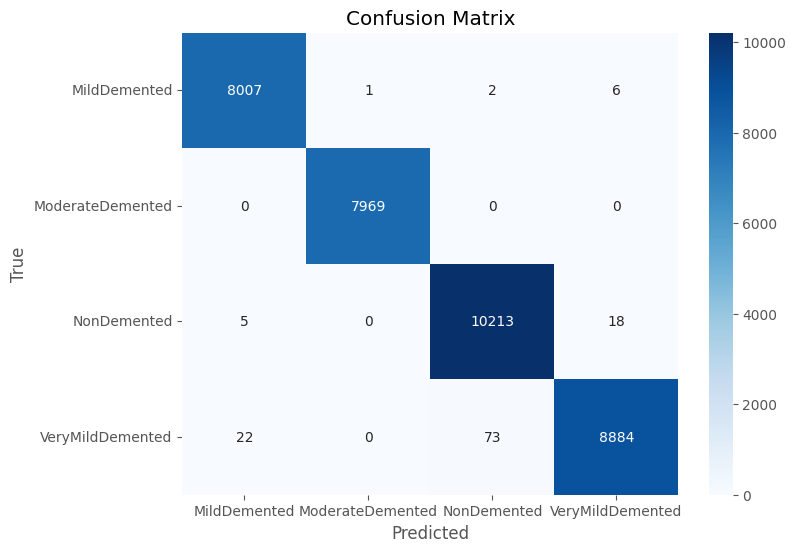


Classification Report:

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00      8016
ModerateDemented       1.00      1.00      1.00      7969
     NonDemented       0.99      1.00      1.00     10236
VeryMildDemented       1.00      0.99      0.99      8979

        accuracy                           1.00     35200
       macro avg       1.00      1.00      1.00     35200
    weighted avg       1.00      1.00      1.00     35200



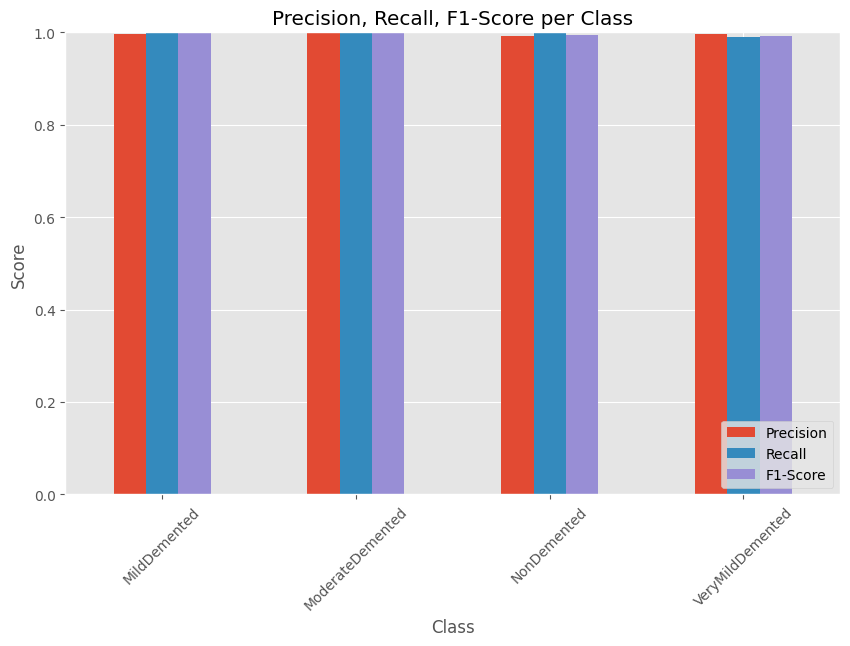

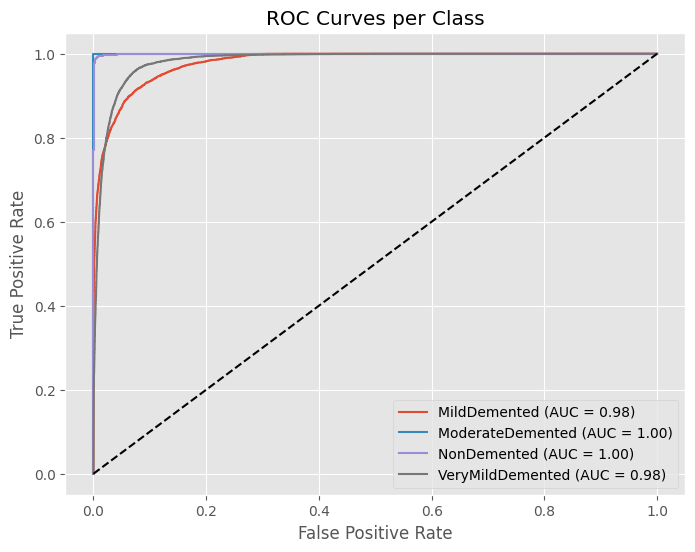

,Class,Precision,Recall,F1-Score,Support
0,MildDemented,0.996639,0.998877,0.997757,8016
1,ModerateDemented,0.999875,1.000000,0.999937,7969
2,NonDemented,0.992710,0.997753,0.995225,10236
3,VeryMildDemented,0.997306,0.989420,0.993347,8979


In [59]:
evaluate_model(to_categorical(train_y),y_train_pred )

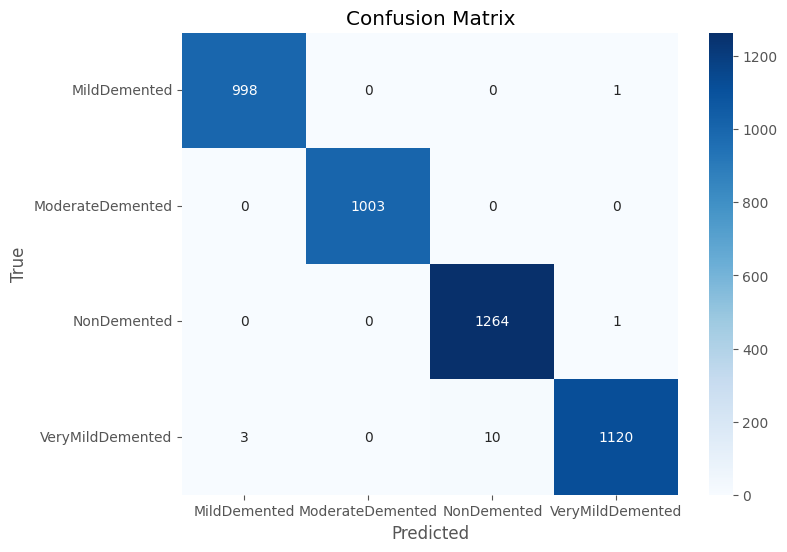


Classification Report:

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00       999
ModerateDemented       1.00      1.00      1.00      1003
     NonDemented       0.99      1.00      1.00      1265
VeryMildDemented       1.00      0.99      0.99      1133

        accuracy                           1.00      4400
       macro avg       1.00      1.00      1.00      4400
    weighted avg       1.00      1.00      1.00      4400



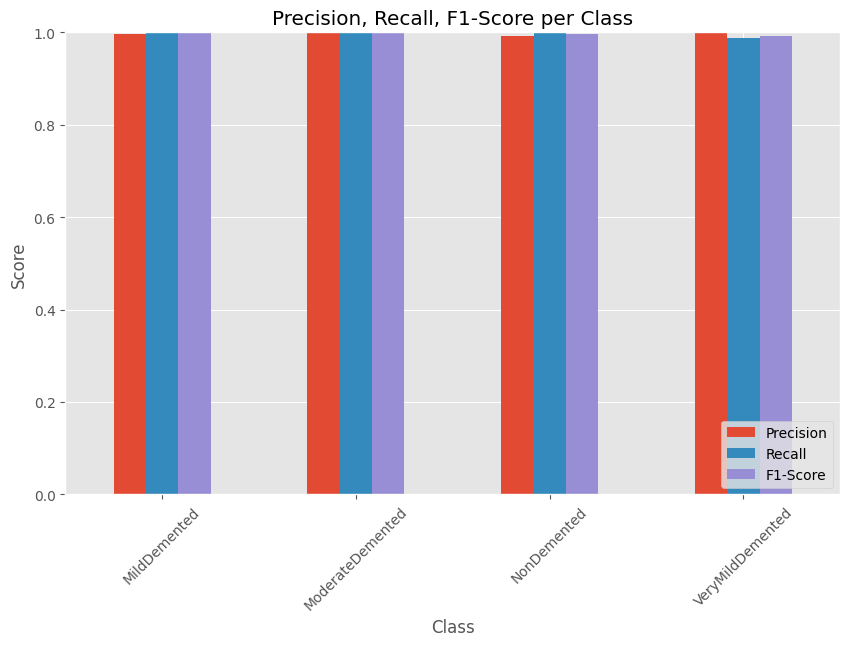

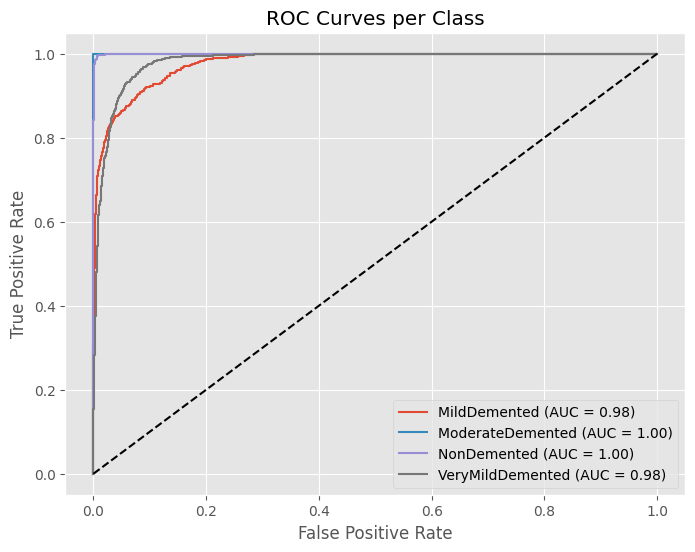

,Class,Precision,Recall,F1-Score,Support
0,MildDemented,0.997003,0.998999,0.998000,999
1,ModerateDemented,1.000000,1.000000,1.000000,1003
2,NonDemented,0.992151,0.999209,0.995668,1265
3,VeryMildDemented,0.998217,0.988526,0.993348,1133


In [60]:
evaluate_model(to_categorical(val_y),y_val_pred )

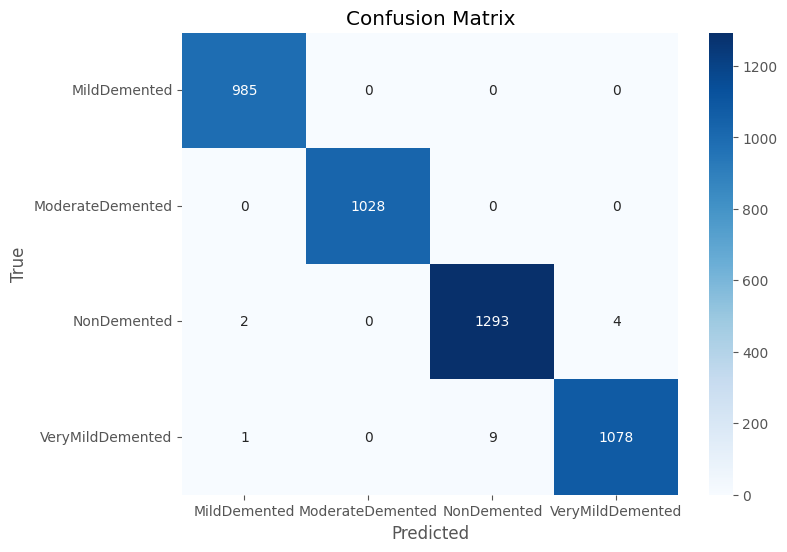


Classification Report:

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00       985
ModerateDemented       1.00      1.00      1.00      1028
     NonDemented       0.99      1.00      0.99      1299
VeryMildDemented       1.00      0.99      0.99      1088

        accuracy                           1.00      4400
       macro avg       1.00      1.00      1.00      4400
    weighted avg       1.00      1.00      1.00      4400



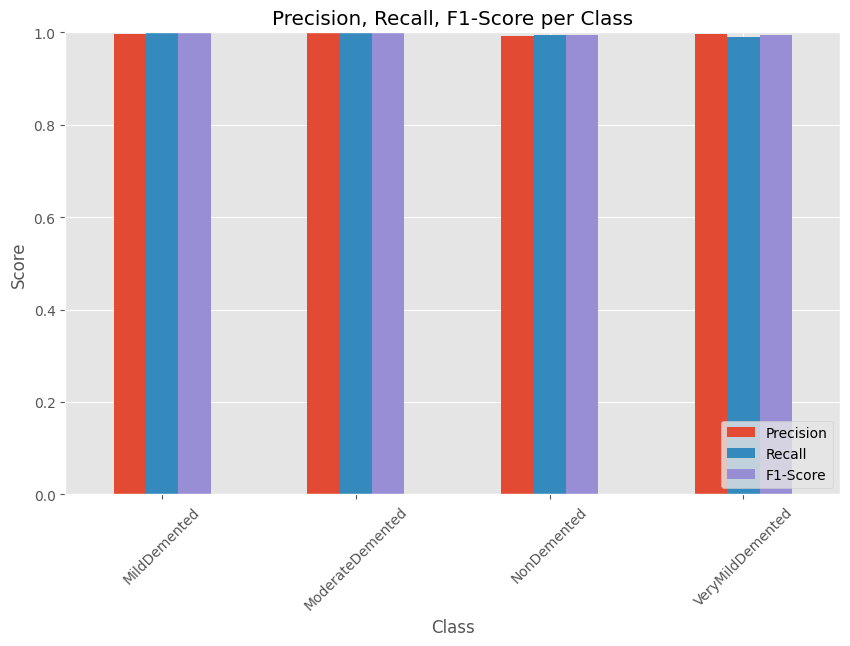

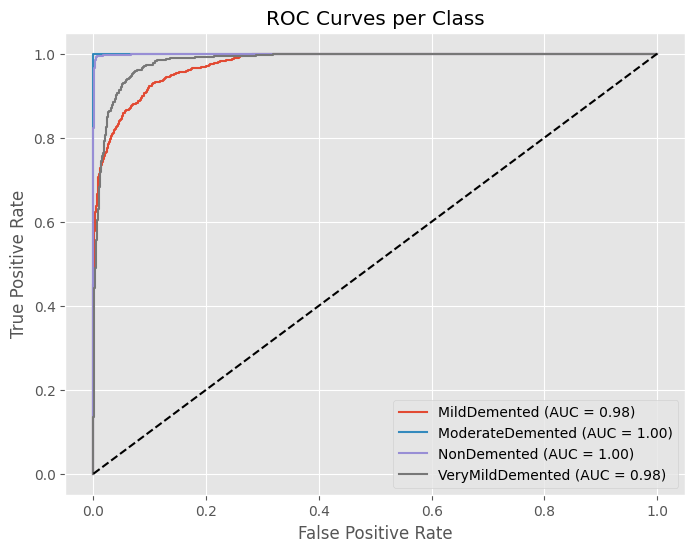

,Class,Precision,Recall,F1-Score,Support
0,MildDemented,0.996964,1.000000,0.998479,985
1,ModerateDemented,1.000000,1.000000,1.000000,1028
2,NonDemented,0.993088,0.995381,0.994233,1299
3,VeryMildDemented,0.996303,0.990809,0.993548,1088


In [61]:
evaluate_model(to_categorical(test_y),y_test_pred )

In [79]:
idx= np.random.randint(0,len(x_test))
num_of_rows = 5
X = x_test[idx:idx+num_of_rows]
y_true = y_test[idx:idx+num_of_rows]
y_pred = y_test_pred[idx:idx+num_of_rows]

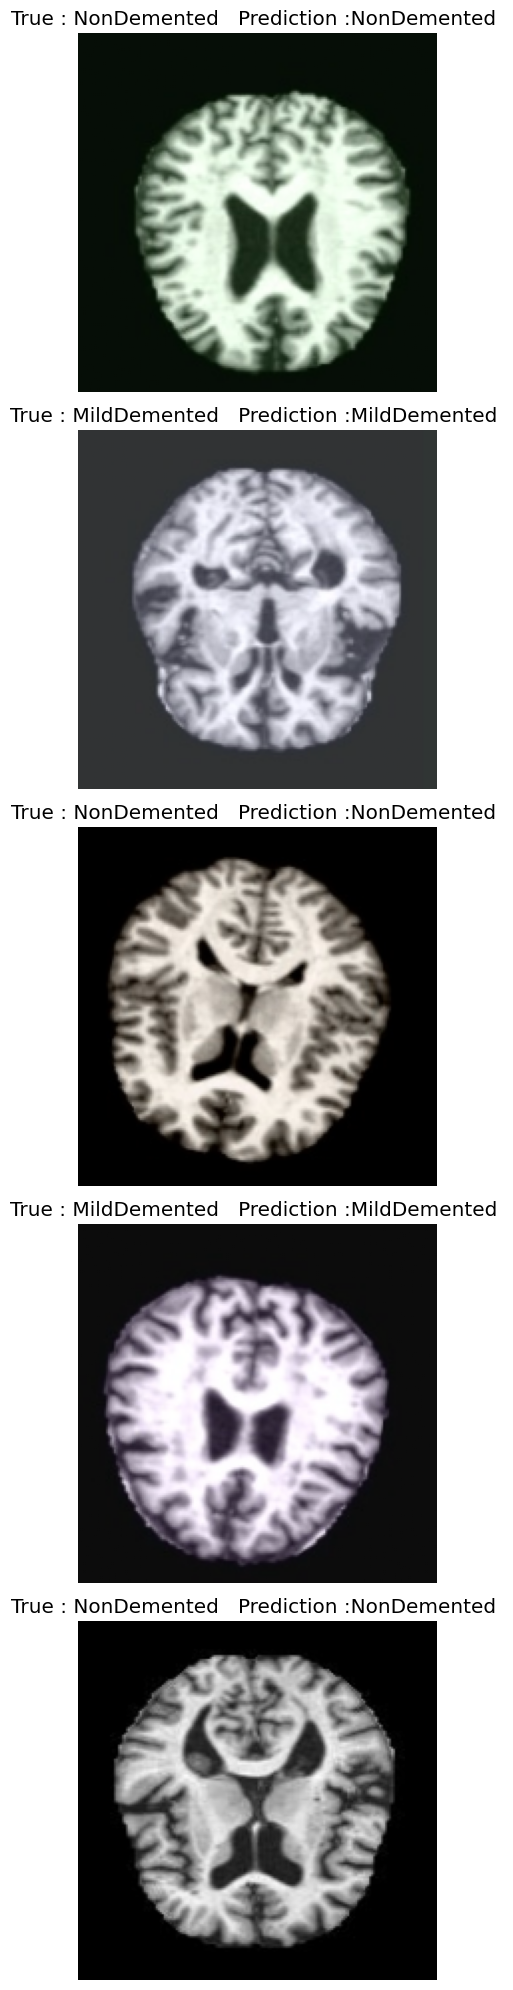

In [80]:
plot_pred( X , y_true , y_pred, num_of_rows , figsize=(20,20))
